<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/aok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

aok log:

<b>oct1</b>

just try points maybe:
https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-point-locations-of-nj-public-private-and-charter-1/about
and subset to camden county or even smaller area and zoom in on that

<b>sep 27</b>

i cleaned up a bit the file--dropped unnecessary stuff so its simpler and easier

made sections for districts and munis

keeping sch districts geo data on ice for now, there is that nice district id we can use later, but this excel file you have here its munis, so downloaded munis file

<b>next steps</b>

merge that earlier xls file you had with school district ids with school districts geo data we have here

In [ ]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

## districts

have nice sections so we dont get lost

In [ ]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School_Districts___Unified_7341673536716239500.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('School_Districts_Unified.shp') #labeled shapefile njSch

In [ ]:
njSch.columns #aok lets see variables
#aok: lets see how the data looks like without geometry field that takes up too much space in the spreadsheet view
njSch[['NJDOE_ID_U', 'DIST_NAME', 'UNSDLEA', 'SD_TYPE', 'GEOID']]
#aok: i like that NJDOE_ID_U field lets try to merge on that
#--there was that other file you had earlier that had these codes

Index(['NJDOE_ID_U', 'DIST_NAME', 'UNSDLEA', 'SD_TYPE', 'GEOID', 'geometry'], dtype='object')

,NJDOE_ID_U,DIST_NAME,UNSDLEA,SD_TYPE,GEOID
0,05-5805,Willingboro Public School District,18000,U,3418000
1,23-4920,South River Public School District,15390,U,3415390
2,23-1170,East Brunswick Township School District,04110,U,3404110
3,23-3290,Monroe Township School District,10500,U,3410500
4,03-1130,Dumont Public School District,03990,U,3403990
...,...,...,...,...,...
334,11-0950,Commercial Township School District,03480,U,3403480
335,11-3050,Maurice River Township School District,09780,U,3409780
336,29-2480,Lacey Township School District,08100,U,3408100
337,29-3820,Ocean Township School District,12090,U,3412090


In [ ]:
#change column names
njSch.rename(columns={'DIST_NAME' : 'District'}, inplace=True)
#make all upper case
njSch['District'] = njSch['District'].str.upper()
njSch[['NJDOE_ID_U', 'District', 'UNSDLEA', 'SD_TYPE', 'GEOID']]

,NJDOE_ID_U,District,UNSDLEA,SD_TYPE,GEOID
0,05-5805,WILLINGBORO PUBLIC SCHOOL DISTRICT,18000,U,3418000
1,23-4920,SOUTH RIVER PUBLIC SCHOOL DISTRICT,15390,U,3415390
2,23-1170,EAST BRUNSWICK TOWNSHIP SCHOOL DISTRICT,04110,U,3404110
3,23-3290,MONROE TOWNSHIP SCHOOL DISTRICT,10500,U,3410500
4,03-1130,DUMONT PUBLIC SCHOOL DISTRICT,03990,U,3403990
...,...,...,...,...,...
334,11-0950,COMMERCIAL TOWNSHIP SCHOOL DISTRICT,03480,U,3403480
335,11-3050,MAURICE RIVER TOWNSHIP SCHOOL DISTRICT,09780,U,3409780
336,29-2480,LACEY TOWNSHIP SCHOOL DISTRICT,08100,U,3408100
337,29-3820,OCEAN TOWNSHIP SCHOOL DISTRICT,12090,U,3412090


<Axes: >

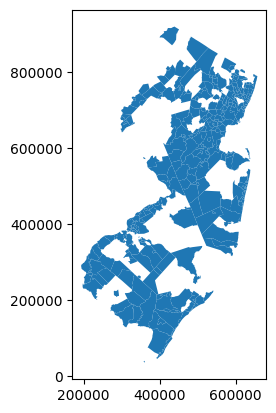

In [ ]:
njSch.plot()

## munis

In [ ]:
#getting munis geo data
! wget -q -O nj-counties.zip https://github.com/theaok/data/raw/refs/heads/main/bounds_nj_shp.zip
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls
mun=gpd.read_file('nj_munis.shp')
mun.columns
mun=mun[mun.COUNTY=='CAMDEN'] #aok: just keeping camden

mun=mun[['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'CENSUS2010', 'SQ_MILES', 'POP2010','geometry']]
mun[['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME']]

nj_counties.cpg       nj_munis_fgdc.xml  nj_state.sbn
nj_counties.dbf       nj_munis.prj	 nj_state.sbx
nj_counties_fgdc.xml  nj_munis.sbn	 nj_state.shp
nj_counties.prj       nj_munis.sbx	 nj_state.shp.xml
nj_counties.sbn       nj_munis.shp	 nj_state.shx
nj_counties.sbx       nj_munis.shp.xml	 sample_data
nj_counties.shp       nj_munis.shx	 School_Districts_Unified.cpg
nj_counties.shp.xml   nj-schools.zip	 School_Districts_Unified.dbf
nj_counties.shx       nj_state.cpg	 School_Districts_Unified.prj
nj-counties.zip       nj_state.dbf	 School_Districts_Unified.shp
nj_munis.cpg	      nj_state_fgdc.xml  School_Districts_Unified.shp.xml
nj_munis.dbf	      nj_state.prj	 School_Districts_Unified.shx


Index(['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'CENSUS2010', 'ACRES', 'SQ_MILES', 'POP2010',
       'POP2000', 'POP1990', 'POP1980', 'POPDEN2010', 'POPDEN2000',
       'POPDEN1990', 'POPDEN1980', 'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME
68,CHESILHURST BORO,CAMDEN,Chesilhurst Borough,Borough,Chesilhurst Borough,Borough of Chesilhurst
78,WINSLOW TWP,CAMDEN,Winslow Township,Township,Winslow Township,Township of Winslow
80,WATERFORD TWP,CAMDEN,Waterford Township,Township,Waterford Township,Township of Waterford
82,PINE VALLEY BORO,CAMDEN,Pine Valley Borough,Borough,Pine Valley Borough,Borough of Pine Valley
86,PINE HILL BORO,CAMDEN,Pine Hill Borough,Borough,Pine Hill Borough,Borough of Pine Hill
87,BERLIN BORO,CAMDEN,Berlin Borough,Borough,Berlin Borough,Borough of Berlin
88,CLEMENTON BORO,CAMDEN,Clementon Borough,Borough,Clementon Borough,Borough of Clementon
89,LAUREL SPRINGS BORO,CAMDEN,Laurel Springs Borough,Borough,Laurel Springs Borough,Borough of Laurel Springs
94,LINDENWOLD BORO,CAMDEN,Lindenwold Borough,Borough,Lindenwold Borough,Borough of Lindenwold
95,STRATFORD BORO,CAMDEN,Stratford Borough,Borough,Stratford Borough,Borough of Stratford


In [ ]:
#aok: i see from excel file that we need to adjust here some strings
mun['MUN'] = mun['MUN'].str.replace(r'TWP$', 'TOWNSHIP', regex=True)
mun['MUN'] = mun['MUN'].str.replace(r'BORO$', 'BOROUGH', regex=True)
mun

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,CENSUS2010,SQ_MILES,POP2010,geometry
68,CHESILHURST BOROUGH,CAMDEN,Chesilhurst Borough,Borough,Chesilhurst Borough,Borough of Chesilhurst,885183,0410,0410,3400712550,1.724713,1634,"POLYGON ((390827.647 326435.522, 390962.671 32..."
78,WINSLOW TOWNSHIP,CAMDEN,Winslow Township,Township,Winslow Township,Township of Winslow,882150,0436,0436,3400781740,58.235150,39499,"POLYGON ((368609.977 344389.586, 368631.27 344..."
80,WATERFORD TOWNSHIP,CAMDEN,Waterford Township,Township,Waterford Township,Township of Waterford,882151,0435,0435,3400777630,36.208074,10649,"POLYGON ((390010.824 347041.203, 390039.55 347..."
82,PINE VALLEY BOROUGH,CAMDEN,Pine Valley Borough,Borough,Pine Valley Borough,Borough of Pine Valley,885353,0429,0429,3400758920,0.974245,12,"POLYGON ((358835.482 350000.847, 359017.05 349..."
86,PINE HILL BOROUGH,CAMDEN,Pine Hill Borough,Borough,Pine Hill Borough,Borough of Pine Hill,885352,0428,0428,3400758770,3.950213,10233,"POLYGON ((356425.878 351654.302, 355962.259 35..."
87,BERLIN BOROUGH,CAMDEN,Berlin Borough,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3400705440,3.615787,7588,"POLYGON ((377510.493 346451.669, 377460.13 346..."
88,CLEMENTON BOROUGH,CAMDEN,Clementon Borough,Borough,Clementon Borough,Borough of Clementon,885186,0411,0411,3400713420,1.951029,5000,"POLYGON ((359403.668 355071.62, 359422.06 3550..."
89,LAUREL SPRINGS BOROUGH,CAMDEN,Laurel Springs Borough,Borough,Laurel Springs Borough,Borough of Laurel Springs,885272,0420,0420,3400739210,0.461237,1908,"POLYGON ((352202.822 361778.626, 352218.711 36..."
94,LINDENWOLD BOROUGH,CAMDEN,Lindenwold Borough,Borough,Lindenwold Borough,Borough of Lindenwold,885279,0422,0422,3400740440,3.943867,17613,"POLYGON ((355713.504 364878.907, 355718.95 364..."
95,STRATFORD BOROUGH,CAMDEN,Stratford Borough,Borough,Stratford Borough,Borough of Stratford,885411,0432,0432,3400771220,1.573850,7040,"POLYGON ((349762.36 365329.99, 350343.747 3649..."


<Axes: >

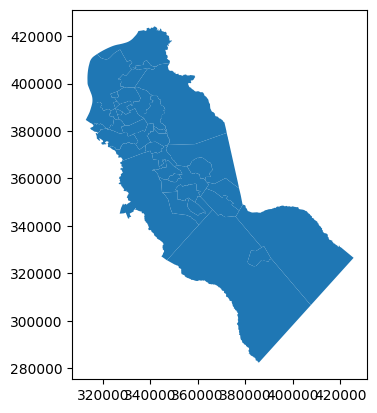

In [ ]:
mun.plot()

In [ ]:
EnrXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20School%20Enrollment%20by%20School%20Level%202024%20-%20Public%20School%20Only.xlsx')
EnrXls

,,"Audubon borough, Camden County, New Jersey","Audubon Park borough, Camden County, New Jersey","Barrington borough, Camden County, New Jersey","Bellmawr borough, Camden County, New Jersey","Berlin borough, Camden County, New Jersey","Berlin township, Camden County, New Jersey","Brooklawn borough, Camden County, New Jersey","Camden city, Camden County, New Jersey","Cherry Hill township, Camden County, New Jersey",...,"Pennsauken township, Camden County, New Jersey","Pine Hill borough, Camden County, New Jersey","Runnemede borough, Camden County, New Jersey","Somerdale borough, Camden County, New Jersey","Stratford borough, Camden County, New Jersey","Tavistock borough, Camden County, New Jersey","Voorhees township, Camden County, New Jersey","Waterford township, Camden County, New Jersey","Winslow township, Camden County, New Jersey","Woodlynne borough, Camden County, New Jersey"
0,Pre-School,90,0,11,128,26,26,4,987,332,...,298,250,100,93,32,0,67,199,118,10
1,K-8,767,50,277,1296,917,509,145,8628,7492,...,3725,855,601,366,673,2,3439,1029,3284,408
2,9-12,265,36,262,483,527,219,59,4221,2957,...,1869,463,326,168,301,0,1632,281,2049,204


In [ ]:
EnrXls = (EnrXls
  .rename(columns={EnrXls.columns[0]: 'School_Level'}) # Rename the first unnamed column
  .melt(
      id_vars=['School_Level'],
      var_name='mun', # aok these are munis not districts
      value_name='Enrollment' # New column for enrollment values
  )
)

# Clean up district names (remove ', Camden County, New Jersey')
EnrXls['mun'] = EnrXls['mun'].str.replace(', Camden County, New Jersey', '', regex=False).str.strip()
EnrXls['mun'] = EnrXls['mun'].str.upper().str.strip()

# Convert 'Enrollment' to numeric, coercing errors to NaN
EnrXls['Enrollment'] = pd.to_numeric(EnrXls['Enrollment'], errors='coerce')

In [ ]:
enr9_12=EnrXls[EnrXls.School_Level.str.strip()=='9-12'] #aok: keep it simple for now
enr9_12

,School_Level,mun,Enrollment
2,9-12,AUDUBON BOROUGH,265
5,9-12,AUDUBON PARK BOROUGH,36
8,9-12,BARRINGTON BOROUGH,262
11,9-12,BELLMAWR BOROUGH,483
14,9-12,BERLIN BOROUGH,527
17,9-12,BERLIN TOWNSHIP,219
20,9-12,BROOKLAWN BOROUGH,59
23,9-12,CAMDEN CITY,4221
26,9-12,CHERRY HILL TOWNSHIP,2957
29,9-12,CHESILHURST BOROUGH,41


In [ ]:
all = pd.merge(mun, enr9_12, left_on=['MUN'], right_on=['mun'], how='outer', indicator=True)
all.columns
all[['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'SQ_MILES', 'POP2010',
       'School_Level', 'mun', 'Enrollment', '_merge']]

Index(['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'CENSUS2010', 'SQ_MILES', 'POP2010', 'geometry',
       'School_Level', 'mun', 'Enrollment', '_merge'],
      dtype='object')

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,SQ_MILES,POP2010,School_Level,mun,Enrollment,_merge
0,AUDUBON BOROUGH,CAMDEN,Audubon Borough,Borough,Audubon Borough,Borough of Audubon,885144,0401,0401,1.492780,8819.0,9-12,AUDUBON BOROUGH,265.0,both
1,AUDUBON PARK BOROUGH,CAMDEN,Audubon Park Borough,Borough,Audubon Park Borough,Borough of Audubon Park,885145,0402,0402,0.164449,1023.0,9-12,AUDUBON PARK BOROUGH,36.0,both
2,BARRINGTON BOROUGH,CAMDEN,Barrington Borough,Borough,Barrington Borough,Borough of Barrington,885149,0403,0403,1.581156,6983.0,9-12,BARRINGTON BOROUGH,262.0,both
3,BELLMAWR BOROUGH,CAMDEN,Bellmawr Borough,Borough,Bellmawr Borough,Borough of Bellmawr,885154,0404,0404,3.098555,11583.0,9-12,BELLMAWR BOROUGH,483.0,both
4,BERLIN BOROUGH,CAMDEN,Berlin Borough,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3.615787,7588.0,9-12,BERLIN BOROUGH,527.0,both
5,BERLIN TOWNSHIP,CAMDEN,Berlin Township,Township,Berlin Township,Township of Berlin,882152,0406,0406,3.339695,5357.0,9-12,BERLIN TOWNSHIP,219.0,both
6,BROOKLAWN BOROUGH,CAMDEN,Brooklawn Borough,Borough,Brooklawn Borough,Borough of Brooklawn,885172,0407,0407,0.530921,1955.0,9-12,BROOKLAWN BOROUGH,59.0,both
7,CAMDEN CITY,CAMDEN,Camden City,City,Camden,City of Camden,885177,0408,0408,10.465581,77344.0,9-12,CAMDEN CITY,4221.0,both
8,CHERRY HILL TOWNSHIP,CAMDEN,Cherry Hill Township,Township,Cherry Hill Township,Township of Cherry Hill,882155,0409,0409,24.178565,71045.0,9-12,CHERRY HILL TOWNSHIP,2957.0,both
9,CHESILHURST BOROUGH,CAMDEN,Chesilhurst Borough,Borough,Chesilhurst Borough,Borough of Chesilhurst,885183,0410,0410,1.724713,1634.0,9-12,CHESILHURST BOROUGH,41.0,both


In [ ]:
#i investigated and see that gloucester city didnt match so fix that and merge again
enr9_12.loc[enr9_12['mun'] == 'GLOUCESTER CITY CITY','mun'] = 'GLOUCESTER CITY'
all = pd.merge(mun, enr9_12, left_on=['MUN'], right_on=['mun'], how='outer', indicator=True)
all.columns
all[['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'SQ_MILES', 'POP2010',
       'School_Level', 'mun', 'Enrollment', '_merge']]
#aok: ok i looked thru and only mt ephraim and pine valley on left_only
#so thats fine they were not on the right

Index(['MUN', 'COUNTY', 'MUN_LABEL', 'MUN_TYPE', 'NAME', 'GNIS_NAME', 'GNIS',
       'SSN', 'MUN_CODE', 'CENSUS2010', 'SQ_MILES', 'POP2010', 'geometry',
       'School_Level', 'mun', 'Enrollment', '_merge'],
      dtype='object')

,MUN,COUNTY,MUN_LABEL,MUN_TYPE,NAME,GNIS_NAME,GNIS,SSN,MUN_CODE,SQ_MILES,POP2010,School_Level,mun,Enrollment,_merge
0,AUDUBON BOROUGH,CAMDEN,Audubon Borough,Borough,Audubon Borough,Borough of Audubon,885144,0401,0401,1.492780,8819,9-12,AUDUBON BOROUGH,265.0,both
1,AUDUBON PARK BOROUGH,CAMDEN,Audubon Park Borough,Borough,Audubon Park Borough,Borough of Audubon Park,885145,0402,0402,0.164449,1023,9-12,AUDUBON PARK BOROUGH,36.0,both
2,BARRINGTON BOROUGH,CAMDEN,Barrington Borough,Borough,Barrington Borough,Borough of Barrington,885149,0403,0403,1.581156,6983,9-12,BARRINGTON BOROUGH,262.0,both
3,BELLMAWR BOROUGH,CAMDEN,Bellmawr Borough,Borough,Bellmawr Borough,Borough of Bellmawr,885154,0404,0404,3.098555,11583,9-12,BELLMAWR BOROUGH,483.0,both
4,BERLIN BOROUGH,CAMDEN,Berlin Borough,Borough,Berlin Borough,Borough of Berlin,885158,0405,0405,3.615787,7588,9-12,BERLIN BOROUGH,527.0,both
5,BERLIN TOWNSHIP,CAMDEN,Berlin Township,Township,Berlin Township,Township of Berlin,882152,0406,0406,3.339695,5357,9-12,BERLIN TOWNSHIP,219.0,both
6,BROOKLAWN BOROUGH,CAMDEN,Brooklawn Borough,Borough,Brooklawn Borough,Borough of Brooklawn,885172,0407,0407,0.530921,1955,9-12,BROOKLAWN BOROUGH,59.0,both
7,CAMDEN CITY,CAMDEN,Camden City,City,Camden,City of Camden,885177,0408,0408,10.465581,77344,9-12,CAMDEN CITY,4221.0,both
8,CHERRY HILL TOWNSHIP,CAMDEN,Cherry Hill Township,Township,Cherry Hill Township,Township of Cherry Hill,882155,0409,0409,24.178565,71045,9-12,CHERRY HILL TOWNSHIP,2957.0,both
9,CHESILHURST BOROUGH,CAMDEN,Chesilhurst Borough,Borough,Chesilhurst Borough,Borough of Chesilhurst,885183,0410,0410,1.724713,1634,9-12,CHESILHURST BOROUGH,41.0,both


In [ ]:
all.dtypes
#import numpy as np
#all['Enrollment'] = all['Enrollment'].fillna(np.nan).astype(int)

,0
MUN,object
COUNTY,object
MUN_LABEL,object
MUN_TYPE,object
NAME,object
GNIS_NAME,object
GNIS,object
SSN,object
MUN_CODE,object
CENSUS2010,object


<Axes: >

Text(0.5, 1.0, 'Total Students Enrolled in Public School\n2024 - 2025 School Year')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

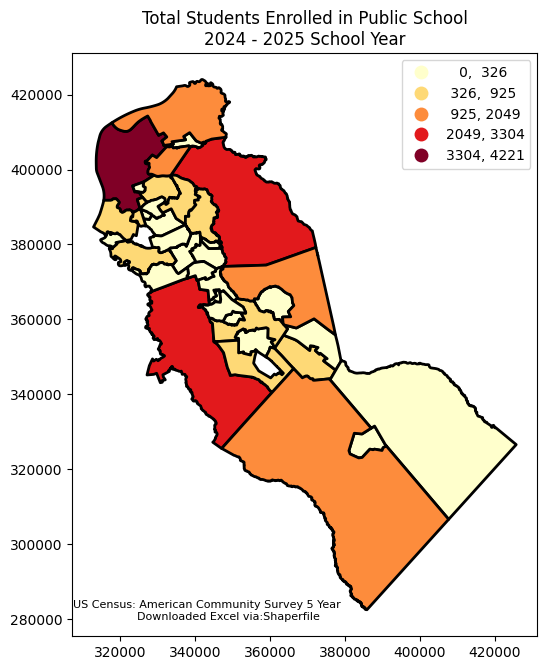

In [ ]:
fig, ax = plt.subplots(figsize=(6,8))

all.plot(ax=ax,figsize=(6,8),column='Enrollment',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Total Students Enrolled in Public School
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )